In [6]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import time

from sklearn.preprocessing import MinMaxScaler, LabelEncoder

In [2]:

#Set parameters to see all data
pd.set_option('display.max_rows', 150)
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 1000)

In [11]:
%%time

# Read dataset
synnepha_exercise_aws_cur_path = '../synnepha_exercise_90d/synnepha_exercise_aws_cur_sample_90d.csv'

try:
    synnepha_exercise_aws_cur_df = pd.read_csv(synnepha_exercise_aws_cur_path)
except pd.errors.ParserError as e:
    print(f'Error while parsing CSV file: {e}')



synnepha_exercise_aws_cur_df.shape

CPU times: user 11.5 ms, sys: 4.06 ms, total: 15.6 ms
Wall time: 14.8 ms


(8100, 8)

In [12]:
%%time

# Read dataset
synnepha_exercise_k8s_metrics_path = '../synnepha_exercise_90d/synnepha_exercise_k8s_metrics_90d.csv'

try:
    synnepha_exercise_k8s_metrics_df = pd.read_csv(synnepha_exercise_k8s_metrics_path)
except pd.errors.ParserError as e:
    print(f'Error while parsing CSV file: {e}')



synnepha_exercise_k8s_metrics_df.shape

CPU times: user 16.2 ms, sys: 11 ms, total: 27.2 ms
Wall time: 30.3 ms


(15120, 8)

In [23]:
k8s_metrics_df = synnepha_exercise_k8s_metrics_df.copy()
aws_cur_df = synnepha_exercise_aws_cur_df.copy()

In [25]:
# Show dataset shapes
print("AWS CUR shape:", aws_cur_df.shape)
print("K8s metrics shape:", k8s_metrics_df.shape)

AWS CUR shape: (8100, 8)
K8s metrics shape: (15120, 8)


## Data types and missing values

In [26]:
# Check data types
print("AWS CUR info:")
aws_cur_df.info()

print("\nK8s metrics info:")
k8s_metrics_df.info()

# Check missing values
print("\nAWS CUR missing values:")
display(aws_cur_df.isna().sum())

print("\nK8s metrics missing values:")
display(k8s_metrics_df.isna().sum())

AWS CUR info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8100 entries, 0 to 8099
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   billing_period  8100 non-null   object 
 1   date            8100 non-null   object 
 2   account_id      8100 non-null   object 
 3   service         8100 non-null   object 
 4   usage_type      8100 non-null   object 
 5   region          8100 non-null   object 
 6   cost_usd        8100 non-null   float64
 7   usage_quantity  8100 non-null   float64
dtypes: float64(2), object(6)
memory usage: 506.4+ KB

K8s metrics info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15120 entries, 0 to 15119
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   timestamp          15120 non-null  object 
 1   pod_name           15120 non-null  object 
 2   namespace          15120 non-null  object 
 3   node

billing_period    0
date              0
account_id        0
service           0
usage_type        0
region            0
cost_usd          0
usage_quantity    0
dtype: int64


K8s metrics missing values:


timestamp            0
pod_name             0
namespace            0
node                 0
cpu_usage_cores      0
memory_usage_mb      0
cpu_request_cores    0
memory_request_mb    0
dtype: int64

In [27]:
# Columns Lists
print(aws_cur_df.columns.tolist())
print(k8s_metrics_df.columns.tolist())

['billing_period', 'date', 'account_id', 'service', 'usage_type', 'region', 'cost_usd', 'usage_quantity']
['timestamp', 'pod_name', 'namespace', 'node', 'cpu_usage_cores', 'memory_usage_mb', 'cpu_request_cores', 'memory_request_mb']


## Convert date columns

In [28]:
# Convert date columns to datetime format
aws_cur_df["date"] = pd.to_datetime(aws_cur_df["date"])
k8s_metrics_df["timestamp"] = pd.to_datetime(k8s_metrics_df["timestamp"])

# Create date column from timestamp for daily aggregation
k8s_metrics_df["date"] = k8s_metrics_df["timestamp"].dt.date
k8s_metrics_df["date"] = pd.to_datetime(k8s_metrics_df["date"])

# Check date ranges
print("AWS CUR date range:")
print(aws_cur_df["date"].min(), "to", aws_cur_df["date"].max())

print("\nK8s metrics date range:")
print(k8s_metrics_df["timestamp"].min(), "to", k8s_metrics_df["timestamp"].max())

AWS CUR date range:
2026-01-31 00:00:00 to 2026-04-30 00:00:00

K8s metrics date range:
2026-01-31 00:00:00+00:00 to 2026-04-30 23:00:00+00:00


In [29]:
aws_cur_df.head(2)

,billing_period,date,account_id,service,usage_type,region,cost_usd,usage_quantity
0,2026-01,2026-01-31,acct_001,AmazonEC2,BoxUsage:m5.xlarge,us-east-1,927.48,4780.38
1,2026-01,2026-01-31,acct_001,AmazonEC2,BoxUsage:m5.xlarge,eu-west-1,948.28,4985.43


In [30]:
k8s_metrics_df.head(2)

,timestamp,pod_name,namespace,node,cpu_usage_cores,memory_usage_mb,cpu_request_cores,memory_request_mb,date
0,2026-01-31 00:00:00+00:00,api-gateway-7f8d9,production,node-01,0.1325,199.1,0.5,512,2026-01-31
1,2026-01-31 00:00:00+00:00,batch-processor-1d5f3,production,node-01,0.3767,976.1,1.0,2048,2026-01-31


## Basic descriptive statistics

In [31]:
# Descriptive statistics for numerical columns
print("AWS CUR numerical summary:")
display(aws_cur_df[["cost_usd", "usage_quantity"]].describe())

print("\nK8s metrics numerical summary:")
display(
    k8s_metrics_df[
        ["cpu_usage_cores", "memory_usage_mb", "cpu_request_cores", "memory_request_mb"]
    ].describe()
)

AWS CUR numerical summary:


,cost_usd,usage_quantity
count,8100.000000,8.100000e+03
mean,248.268315,2.041580e+06
std,356.853271,3.808932e+06
min,8.290000,3.220000e+01
25%,60.227500,7.294125e+02
50%,138.190000,2.358385e+03
75%,302.040000,2.881109e+06
max,12612.810000,2.203417e+07



K8s metrics numerical summary:


,cpu_usage_cores,memory_usage_mb,cpu_request_cores,memory_request_mb
count,15120.000000,15120.000000,15120.000000,15120.000000
mean,0.673161,1407.577824,1.464286,2889.142857
std,0.881109,1738.453135,1.227906,2613.344674
min,0.001000,52.400000,0.250000,256.000000
25%,0.135975,207.400000,0.500000,512.000000
50%,0.317900,584.300000,1.000000,2048.000000
75%,0.823100,1946.325000,2.000000,4096.000000
max,12.760300,13530.600000,4.000000,8192.000000


## Cardinality checks

In [32]:
# Check number of unique values in categorical columns
aws_categorical_cols = ["billing_period", "account_id", "service", "usage_type", "region"]
k8s_categorical_cols = ["pod_name", "namespace", "node"]

print("AWS CUR cardinality:")
display(aws_cur_df[aws_categorical_cols].nunique().sort_values(ascending=False))

print("\nK8s metrics cardinality:")
display(k8s_metrics_df[k8s_categorical_cols].nunique().sort_values(ascending=False))

AWS CUR cardinality:


account_id        8
service           6
usage_type        6
billing_period    4
region            4
dtype: int64


K8s metrics cardinality:


pod_name     7
namespace    3
node         3
dtype: int64

## Unique values

In [33]:
# Display unique values for main categorical dimensions
for col in aws_categorical_cols:
    print(f"\nUnique values in {col}:")
    print(aws_cur_df[col].unique())

for col in k8s_categorical_cols:
    print(f"\nUnique values in {col}:")
    print(k8s_metrics_df[col].unique())


Unique values in billing_period:
['2026-01' '2026-02' '2026-03' '2026-04']

Unique values in account_id:
['acct_001' 'acct_002' 'acct_003' 'acct_004' 'acct_005' 'acct_006'
 'acct_007' 'acct_008']

Unique values in service:
['AmazonEC2' 'AmazonS3' 'AmazonRDS' 'AWSLambda' 'AmazonCloudWatch'
 'AmazonEKS']

Unique values in usage_type:
['BoxUsage:m5.xlarge' 'TimedStorage-ByteHrs' 'InstanceUsage:db.r5.large'
 'Lambda-GB-Second' 'MetricMonitorUsage' 'AmazonEKS-Hours:perCluster']

Unique values in region:
['us-east-1' 'eu-west-1' 'us-west-2' 'eu-central-1']

Unique values in pod_name:
['api-gateway-7f8d9' 'batch-processor-1d5f3' 'cache-layer-5f1d9'
 'data-pipeline-4a2c1' 'legacy-etl-2e7b4' 'model-serving-9b3e7'
 'monitoring-agent-6c8a2']

Unique values in namespace:
['production' 'ml-inference' 'observability']

Unique values in node:
['node-01' 'node-02' 'node-03']


## Value Counts

In [34]:
# Display unique values and frequency distributions
aws_categorical_cols = [
    "billing_period",
    "account_id",
    "service",
    "usage_type",
    "region"
]

k8s_categorical_cols = [
    "pod_name",
    "namespace",
    "node"
]

print("=" * 80)
print("AWS CUR CATEGORICAL ANALYSIS")
print("=" * 80)

for col in aws_categorical_cols:

    print(f"\n\nColumn: {col}")
    print("-" * 50)

    print(f"Unique Count: {aws_cur_df[col].nunique()}")

    print("\nTop Values:")
    display(
        aws_cur_df[col]
        .value_counts(dropna=False)
        .reset_index()
        .rename(columns={
            "index": col,
            col: "count"
        })
        .head(20)
    )


print("\n\n")
print("=" * 80)
print("KUBERNETES CATEGORICAL ANALYSIS")
print("=" * 80)

for col in k8s_categorical_cols:

    print(f"\n\nColumn: {col}")
    print("-" * 50)

    print(f"Unique Count: {k8s_metrics_df[col].nunique()}")

    print("\nTop Values:")
    display(
        k8s_metrics_df[col]
        .value_counts(dropna=False)
        .reset_index()
        .rename(columns={
            "index": col,
            col: "count"
        })
        .head(20)
    )

AWS CUR CATEGORICAL ANALYSIS


Column: billing_period
--------------------------------------------------
Unique Count: 4

Top Values:


,count,count
0,2026-03,2790
1,2026-04,2700
2,2026-02,2520
3,2026-01,90




Column: account_id
--------------------------------------------------
Unique Count: 8

Top Values:


,count,count
0,acct_003,1620
1,acct_008,1620
2,acct_001,1080
3,acct_005,1080
4,acct_007,1080
5,acct_002,540
6,acct_004,540
7,acct_006,540




Column: service
--------------------------------------------------
Unique Count: 6

Top Values:


...

,count,count
0,api-gateway-7f8d9,2160
1,batch-processor-1d5f3,2160
2,cache-layer-5f1d9,2160
3,data-pipeline-4a2c1,2160
4,legacy-etl-2e7b4,2160
5,model-serving-9b3e7,2160
6,monitoring-agent-6c8a2,2160




Column: namespace
--------------------------------------------------
Unique Count: 3

Top Values:


,count,count
0,production,10800
1,ml-inference,2160
2,observability,2160




Column: node
--------------------------------------------------
Unique Count: 3

Top Values:


,count,count
0,node-01,6480
1,node-02,4320
2,node-03,4320


## Cost Distribution Analysis

Cost Distribution Summary


count     8100.000000
mean       248.268315
std        356.853271
min          8.290000
50%        138.190000
75%        302.040000
90%        608.639000
95%        782.178500
99%       1547.148400
max      12612.810000
Name: cost_usd, dtype: float64

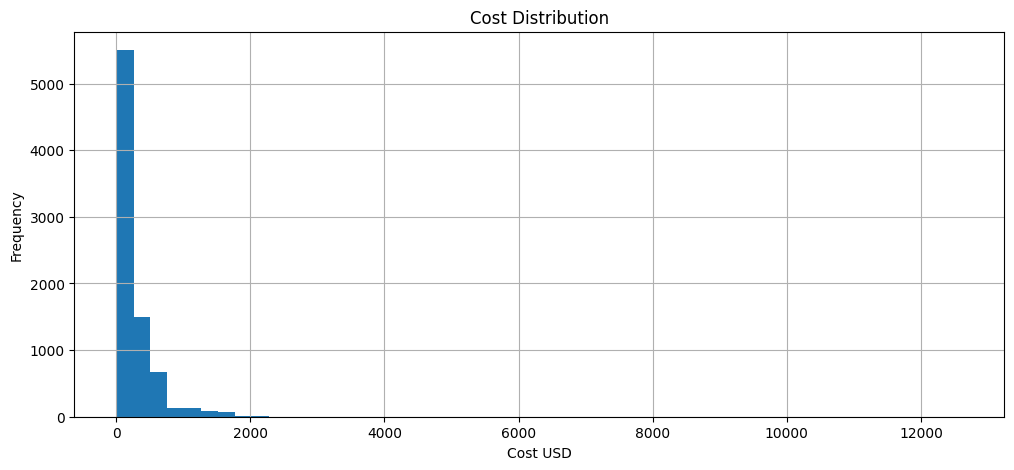

In [35]:
# Analyze cost distribution

print("Cost Distribution Summary")
display(
    aws_cur_df["cost_usd"].describe(
        percentiles=[0.5, 0.75, 0.90, 0.95, 0.99]
    )
)

plt.figure(figsize=(12, 5))
plt.hist(
    aws_cur_df["cost_usd"],
    bins=50
)
plt.title("Cost Distribution")
plt.xlabel("Cost USD")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

In [36]:
# Top expensive combinations

top_costs = (
    aws_cur_df
    .groupby(
        ["service", "usage_type", "region"],
        as_index=False
    )
    .agg(
        total_cost_usd=("cost_usd", "sum"),
        avg_cost_usd=("cost_usd", "mean"),
        max_cost_usd=("cost_usd", "max")
    )
    .sort_values(
        "total_cost_usd",
        ascending=False
    )
)

display(top_costs.head(30))

,service,usage_type,region,total_cost_usd,avg_cost_usd,max_cost_usd
10,AmazonEC2,BoxUsage:m5.xlarge,us-east-1,319545.090,710.100200,12612.810
11,AmazonEC2,BoxUsage:m5.xlarge,us-west-2,287161.080,797.669667,2107.590
9,AmazonEC2,BoxUsage:m5.xlarge,eu-west-1,220858.235,817.993463,11950.065
18,AmazonRDS,InstanceUsage:db.r5.large,us-east-1,152726.720,339.392711,789.170
19,AmazonRDS,InstanceUsage:db.r5.large,us-west-2,147950.690,410.974139,866.090
8,AmazonEC2,BoxUsage:m5.xlarge,eu-central-1,116947.080,433.137333,805.190
17,AmazonRDS,InstanceUsage:db.r5.large,eu-west-1,108284.500,401.053704,779.610
22,AmazonS3,TimedStorage-ByteHrs,us-east-1,80697.310,179.327356,441.290
23,AmazonS3,TimedStorage-ByteHrs,us-west-2,76172.110,211.589194,506.790
14,AmazonEKS,AmazonEKS-Hours:perCluster,us-east-1,64797.950,143.995444,389.150


## Daily total AWS cost

In [38]:
# Aggregate total cost by day
daily_cost_df = (
    aws_cur_df
    .groupby("date", as_index=False)
    .agg(
        total_cost_usd=("cost_usd", "sum"),
        total_usage_quantity=("usage_quantity", "sum")
    )
    .sort_values("date")
)

display(
    pd.concat([
        daily_cost_df.head(),
        daily_cost_df.tail()
    ])
)

print("Number of daily observations:", daily_cost_df.shape[0])

,date,total_cost_usd,total_usage_quantity
0,2026-01-31,16862.60,1.334586e+08
1,2026-02-01,17107.44,1.333144e+08
2,2026-02-02,24095.45,2.112864e+08
3,2026-02-03,23620.45,2.013512e+08
4,2026-02-04,23736.00,2.092913e+08
85,2026-04-26,17512.82,1.322096e+08
86,2026-04-27,23640.68,2.013512e+08
87,2026-04-28,26272.61,2.426937e+08
88,2026-04-29,27743.61,2.353472e+08
89,2026-04-30,27440.17,2.361925e+08


Number of daily observations: 90


## Plot daily total cost

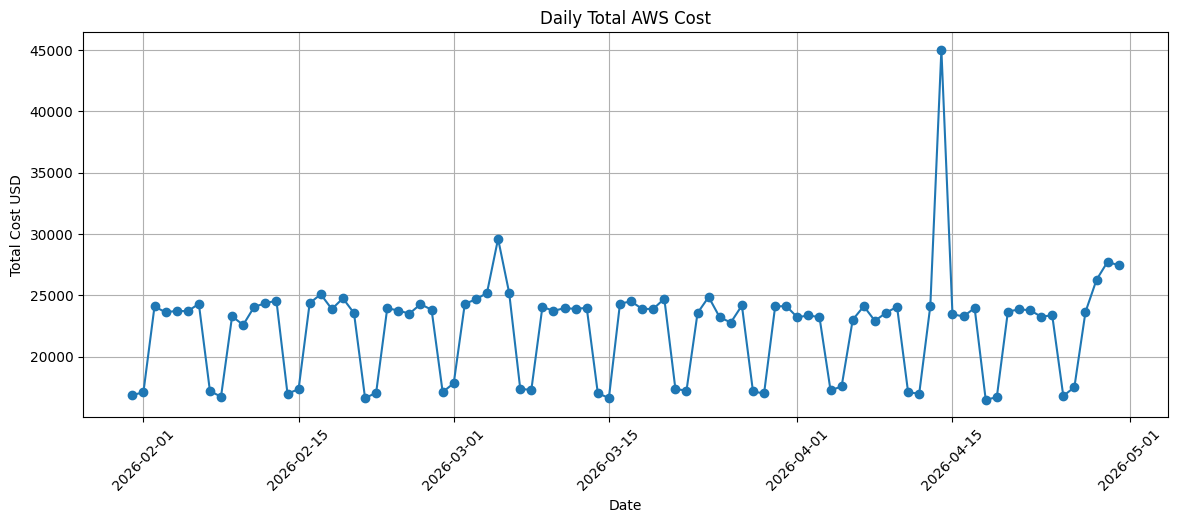

In [39]:
# Plot daily total AWS cost
plt.figure(figsize=(14, 5))
plt.plot(daily_cost_df["date"], daily_cost_df["total_cost_usd"], marker="o")
plt.title("Daily Total AWS Cost")
plt.xlabel("Date")
plt.ylabel("Total Cost USD")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

## Daily cost by service

In [40]:
# Aggregate daily cost by service
daily_service_cost_df = (
    aws_cur_df
    .groupby(["date", "service"], as_index=False)
    .agg(total_cost_usd=("cost_usd", "sum"))
    .sort_values(["date", "service"])
)

# Pivot for easier visual analysis
daily_service_cost_pivot = daily_service_cost_df.pivot(
    index="date",
    columns="service",
    values="total_cost_usd"
).fillna(0)

display(daily_service_cost_pivot.head())

service,AWSLambda,AmazonCloudWatch,AmazonEC2,AmazonEKS,AmazonRDS,AmazonS3
date,,,,,,
2026-01-31,558.40,500.27,7121.29,1619.45,4761.65,2301.54
2026-02-01,559.76,503.28,7270.16,1674.60,4803.61,2296.03
2026-02-02,1385.64,572.68,11436.45,2324.35,5445.39,2930.94
2026-02-03,1269.08,594.33,10959.56,2438.70,5470.31,2888.47
2026-02-04,1311.74,550.06,11138.71,2422.21,5315.47,2997.81


## Plot daily cost by service

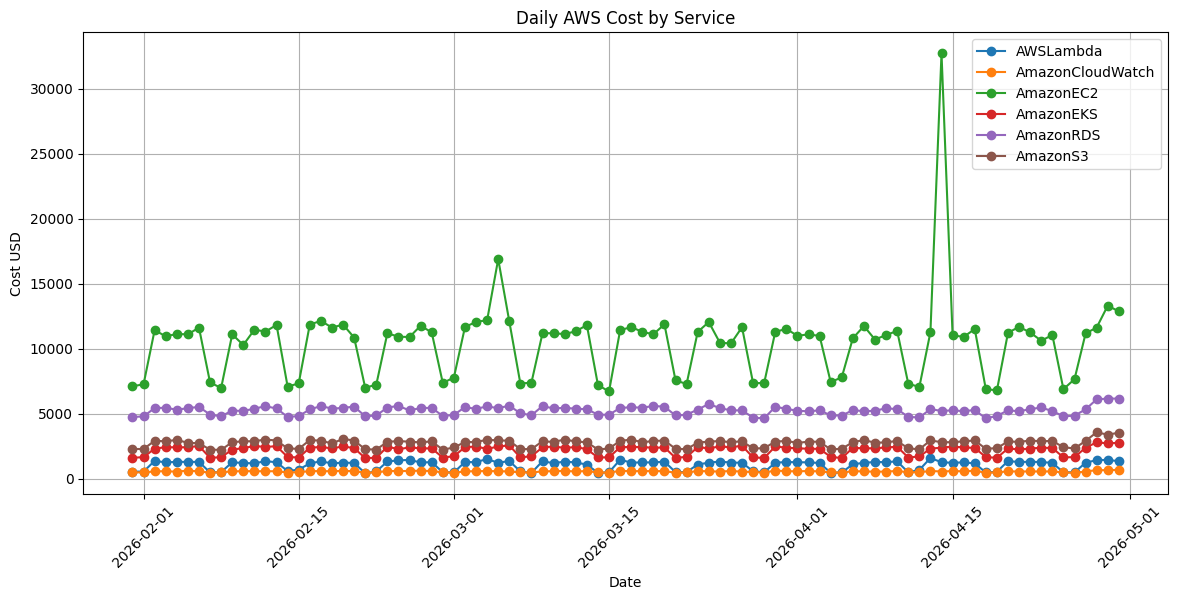

In [41]:
# Plot daily AWS cost by service
plt.figure(figsize=(14, 6))

for service in daily_service_cost_pivot.columns:
    plt.plot(
        daily_service_cost_pivot.index,
        daily_service_cost_pivot[service],
        marker="o",
        label=service
    )

plt.title("Daily AWS Cost by Service")
plt.xlabel("Date")
plt.ylabel("Cost USD")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

## Cost contribution by service

In [42]:
# Calculate total cost contribution by service
service_cost_summary = (
    aws_cur_df
    .groupby("service", as_index=False)
    .agg(
        total_cost_usd=("cost_usd", "sum"),
        avg_daily_cost_usd=("cost_usd", "mean"),
        total_usage_quantity=("usage_quantity", "sum")
    )
    .sort_values("total_cost_usd", ascending=False)
)

service_cost_summary["cost_share_pct"] = (
    service_cost_summary["total_cost_usd"] /
    service_cost_summary["total_cost_usd"].sum()
) * 100

display(service_cost_summary)

,service,total_cost_usd,avg_daily_cost_usd,total_usage_quantity,cost_share_pct
2,AmazonEC2,944511.485,699.638137,4.920445e+06,46.967877
4,AmazonRDS,473719.810,350.903563,1.974668e+06,23.556742
5,AmazonS3,246826.690,182.834585,1.072687e+10,12.273991
3,AmazonEKS,198283.170,146.876422,1.982538e+06,9.860060
0,AWSLambda,96685.785,71.619100,5.800880e+09,4.807910
1,AmazonCloudWatch,50946.410,37.738081,1.697868e+05,2.533420


## Cost contribution by region

In [43]:
# Calculate total cost contribution by region
region_cost_summary = (
    aws_cur_df
    .groupby("region", as_index=False)
    .agg(
        total_cost_usd=("cost_usd", "sum"),
        avg_cost_usd=("cost_usd", "mean"),
        total_usage_quantity=("usage_quantity", "sum")
    )
    .sort_values("total_cost_usd", ascending=False)
)

region_cost_summary["cost_share_pct"] = (
    region_cost_summary["total_cost_usd"] /
    region_cost_summary["total_cost_usd"].sum()
) * 100

display(region_cost_summary)

,region,total_cost_usd,avg_cost_usd,total_usage_quantity,cost_share_pct
2,us-east-1,666074.370,246.694211,5.407546e+09,33.121989
3,us-west-2,618998.575,286.573414,5.127361e+09,30.781043
1,eu-west-1,466908.985,288.215423,3.824019e+09,23.218059
0,eu-central-1,258991.420,159.871247,2.177874e+09,12.878909


## Service-region cost summary

In [44]:
# Analyze cost by service and region
service_region_summary = (
    aws_cur_df
    .groupby(["service", "region"], as_index=False)
    .agg(
        total_cost_usd=("cost_usd", "sum"),
        avg_cost_usd=("cost_usd", "mean"),
        max_cost_usd=("cost_usd", "max"),
        total_usage_quantity=("usage_quantity", "sum")
    )
    .sort_values("total_cost_usd", ascending=False)
)

display(service_region_summary)

,service,region,total_cost_usd,avg_cost_usd,max_cost_usd,total_usage_quantity
10,AmazonEC2,us-east-1,319545.090,710.100200,12612.810,1.665301e+06
11,AmazonEC2,us-west-2,287161.080,797.669667,2107.590,1.496275e+06
9,AmazonEC2,eu-west-1,220858.235,817.993463,11950.065,1.149860e+06
18,AmazonRDS,us-east-1,152726.720,339.392711,789.170,6.360639e+05
19,AmazonRDS,us-west-2,147950.690,410.974139,866.090,6.170910e+05
8,AmazonEC2,eu-central-1,116947.080,433.137333,805.190,6.090086e+05
17,AmazonRDS,eu-west-1,108284.500,401.053704,779.610,4.516597e+05
22,AmazonS3,us-east-1,80697.310,179.327356,441.290,3.507766e+09
23,AmazonS3,us-west-2,76172.110,211.589194,506.790,3.310674e+09
14,AmazonEKS,us-east-1,64797.950,143.995444,389.150,6.480619e+05


## Daily Kubernetes utilization

In [45]:
# Aggregate Kubernetes metrics by day
daily_k8s_df = (
    k8s_metrics_df
    .groupby("date", as_index=False)
    .agg(
        avg_cpu_usage_cores=("cpu_usage_cores", "mean"),
        max_cpu_usage_cores=("cpu_usage_cores", "max"),
        avg_memory_usage_mb=("memory_usage_mb", "mean"),
        max_memory_usage_mb=("memory_usage_mb", "max"),
        avg_cpu_request_cores=("cpu_request_cores", "mean"),
        avg_memory_request_mb=("memory_request_mb", "mean")
    )
    .sort_values("date")
)

display(daily_k8s_df.head())

,date,avg_cpu_usage_cores,max_cpu_usage_cores,avg_memory_usage_mb,max_memory_usage_mb,avg_cpu_request_cores,avg_memory_request_mb
0,2026-01-31,0.513221,2.9313,1063.375000,4279.8,1.464286,2889.142857
1,2026-02-01,0.474359,2.3873,1062.485119,4744.0,1.464286,2889.142857
2,2026-02-02,0.693867,3.7165,1514.901786,7818.4,1.464286,2889.142857
3,2026-02-03,0.720204,4.5210,1507.488095,7465.2,1.464286,2889.142857
4,2026-02-04,0.681130,3.6567,1503.398214,7173.2,1.464286,2889.142857


## CPU and memory utilization ratio

In [46]:
# Calculate utilization ratios
k8s_metrics_df["cpu_utilization_ratio"] = (
    k8s_metrics_df["cpu_usage_cores"] / k8s_metrics_df["cpu_request_cores"]
)

k8s_metrics_df["memory_utilization_ratio"] = (
    k8s_metrics_df["memory_usage_mb"] / k8s_metrics_df["memory_request_mb"]
)

# Replace infinite values if any request value is zero
k8s_metrics_df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Summarize utilization ratios by pod
pod_utilization_summary = (
    k8s_metrics_df
    .groupby("pod_name", as_index=False)
    .agg(
        avg_cpu_utilization_ratio=("cpu_utilization_ratio", "mean"),
        max_cpu_utilization_ratio=("cpu_utilization_ratio", "max"),
        avg_memory_utilization_ratio=("memory_utilization_ratio", "mean"),
        max_memory_utilization_ratio=("memory_utilization_ratio", "max"),
        avg_cpu_usage_cores=("cpu_usage_cores", "mean"),
        avg_memory_usage_mb=("memory_usage_mb", "mean")
    )
    .sort_values("max_cpu_utilization_ratio", ascending=False)
)

display(pod_utilization_summary)

,pod_name,avg_cpu_utilization_ratio,max_cpu_utilization_ratio,avg_memory_utilization_ratio,max_memory_utilization_ratio,avg_cpu_usage_cores,avg_memory_usage_mb
5,model-serving-9b3e7,0.590128,3.190075,0.574430,1.651685,2.360513,4705.729491
2,cache-layer-5f1d9,0.627738,1.254800,0.681191,1.252832,0.313869,697.539444
3,data-pipeline-4a2c1,0.534376,1.134450,0.634937,1.421387,1.068752,2600.703750
6,monitoring-agent-6c8a2,0.538822,1.085600,0.628067,1.081250,0.134706,160.785231
0,api-gateway-7f8d9,0.466668,1.057000,0.621099,1.200391,0.233334,318.002731
1,batch-processor-1d5f3,0.529298,1.037900,0.616367,1.101465,0.529298,1262.318611
4,legacy-etl-2e7b4,0.035829,0.073300,0.026359,0.048755,0.071659,107.965509


## Plot daily Kubernetes CPU and memory usage

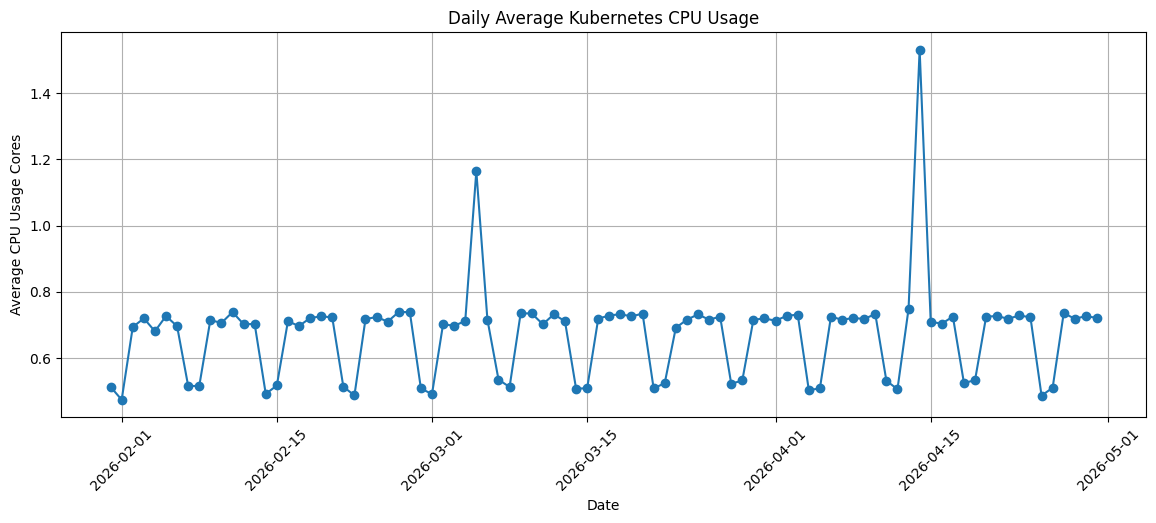

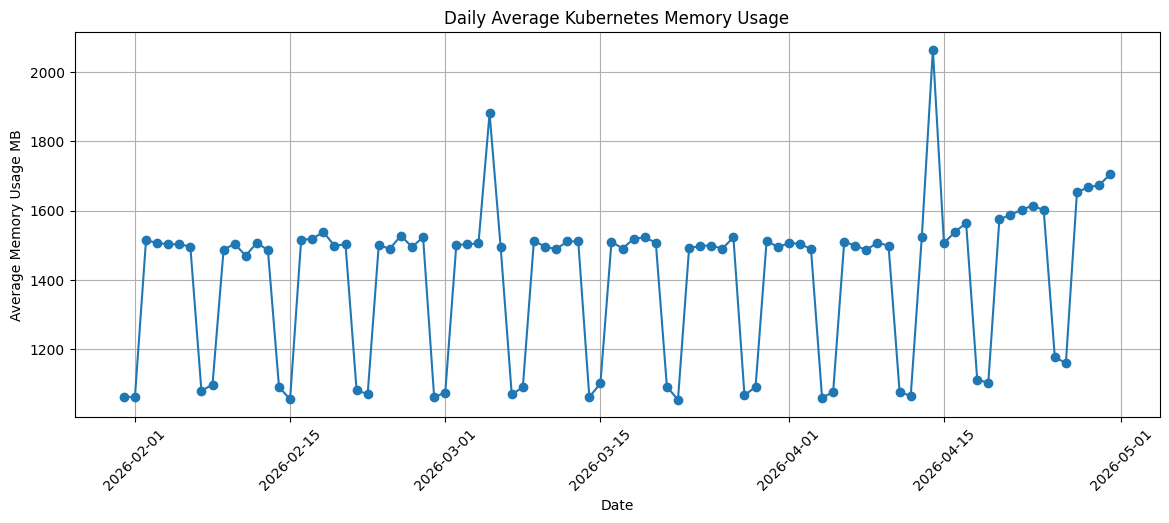

In [47]:
# Plot daily average CPU usage
plt.figure(figsize=(14, 5))
plt.plot(daily_k8s_df["date"], daily_k8s_df["avg_cpu_usage_cores"], marker="o")
plt.title("Daily Average Kubernetes CPU Usage")
plt.xlabel("Date")
plt.ylabel("Average CPU Usage Cores")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

# Plot daily average memory usage
plt.figure(figsize=(14, 5))
plt.plot(daily_k8s_df["date"], daily_k8s_df["avg_memory_usage_mb"], marker="o")
plt.title("Daily Average Kubernetes Memory Usage")
plt.xlabel("Date")
plt.ylabel("Average Memory Usage MB")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

## Join daily AWS cost and Kubernetes metrics

In [49]:
# Join daily AWS cost with daily Kubernetes metrics
daily_combined_df = daily_cost_df.merge(
    daily_k8s_df,
    on="date",
    how="left"
)

display(
    pd.concat([
        daily_combined_df.head(),
        daily_combined_df.tail()
    ])
)


,date,total_cost_usd,total_usage_quantity,avg_cpu_usage_cores,max_cpu_usage_cores,avg_memory_usage_mb,max_memory_usage_mb,avg_cpu_request_cores,avg_memory_request_mb
0,2026-01-31,16862.60,1.334586e+08,0.513221,2.9313,1063.375000,4279.8,1.464286,2889.142857
1,2026-02-01,17107.44,1.333144e+08,0.474359,2.3873,1062.485119,4744.0,1.464286,2889.142857
2,2026-02-02,24095.45,2.112864e+08,0.693867,3.7165,1514.901786,7818.4,1.464286,2889.142857
3,2026-02-03,23620.45,2.013512e+08,0.720204,4.5210,1507.488095,7465.2,1.464286,2889.142857
4,2026-02-04,23736.00,2.092913e+08,0.681130,3.6567,1503.398214,7173.2,1.464286,2889.142857
85,2026-04-26,17512.82,1.322096e+08,0.510510,2.2469,1159.996429,4123.7,1.464286,2889.142857
86,2026-04-27,23640.68,2.013512e+08,0.735788,3.8092,1654.015476,7232.1,1.464286,2889.142857
87,2026-04-28,26272.61,2.426937e+08,0.719107,4.0067,1667.354762,7665.8,1.464286,2889.142857
88,2026-04-29,27743.61,2.353472e+08,0.726661,4.1381,1674.214286,7549.1,1.464286,2889.142857
89,2026-04-30,27440.17,2.361925e+08,0.721495,3.9735,1705.080357,7430.7,1.464286,2889.142857


## Correlation analysis

In [50]:
# Calculate simple correlation between cost and Kubernetes metrics
correlation_cols = [
    "total_cost_usd",
    "total_usage_quantity",
    "avg_cpu_usage_cores",
    "max_cpu_usage_cores",
    "avg_memory_usage_mb",
    "max_memory_usage_mb",
]

correlation_matrix = daily_combined_df[correlation_cols].corr()

display(correlation_matrix["total_cost_usd"].sort_values(ascending=False))
display(correlation_matrix)

total_cost_usd          1.000000
avg_cpu_usage_cores     0.954166
max_memory_usage_mb     0.952594
avg_memory_usage_mb     0.933358
max_cpu_usage_cores     0.883190
total_usage_quantity    0.811248
Name: total_cost_usd, dtype: float64

,total_cost_usd,total_usage_quantity,avg_cpu_usage_cores,max_cpu_usage_cores,avg_memory_usage_mb,max_memory_usage_mb
total_cost_usd,1.000000,0.811248,0.954166,0.883190,0.933358,0.952594
total_usage_quantity,0.811248,1.000000,0.692729,0.528248,0.919798,0.840307
avg_cpu_usage_cores,0.954166,0.692729,1.000000,0.959308,0.886591,0.950385
max_cpu_usage_cores,0.883190,0.528248,0.959308,1.000000,0.764386,0.865701
avg_memory_usage_mb,0.933358,0.919798,0.886591,0.764386,1.000000,0.952515
max_memory_usage_mb,0.952594,0.840307,0.950385,0.865701,0.952515,1.000000


## Top expensive rows

In [52]:
# Inspect the most expensive individual CUR rows
top_expensive_rows = (
    aws_cur_df
    .sort_values("cost_usd", ascending=False)
    .head(20)
)

display(top_expensive_rows)

,billing_period,date,account_id,service,usage_type,region,cost_usd,usage_quantity
6570,2026-04,2026-04-14,acct_001,AmazonEC2,BoxUsage:m5.xlarge,us-east-1,12612.810,65691.570
6571,2026-04,2026-04-14,acct_001,AmazonEC2,BoxUsage:m5.xlarge,eu-west-1,11950.065,62239.975
2971,2026-03,2026-03-05,acct_001,AmazonEC2,BoxUsage:m5.xlarge,eu-west-1,4606.460,23325.360
2970,2026-03,2026-03-05,acct_001,AmazonEC2,BoxUsage:m5.xlarge,us-east-1,3421.820,17557.580
7921,2026-04,2026-04-29,acct_001,AmazonEC2,BoxUsage:m5.xlarge,eu-west-1,2124.270,11063.920
3702,2026-03,2026-03-13,acct_002,AmazonEC2,BoxUsage:m5.xlarge,us-west-2,2107.590,10947.030
5232,2026-03,2026-03-30,acct_002,AmazonEC2,BoxUsage:m5.xlarge,us-west-2,2072.690,10828.730
1182,2026-02,2026-02-13,acct_002,AmazonEC2,BoxUsage:m5.xlarge,us-west-2,2060.290,10889.490
4681,2026-03,2026-03-24,acct_001,AmazonEC2,BoxUsage:m5.xlarge,eu-west-1,2060.080,10658.500
6222,2026-04,2026-04-10,acct_002,AmazonEC2,BoxUsage:m5.xlarge,us-west-2,1952.080,10167.070


## Largest daily cost changes

In [53]:
# Calculate day-over-day cost changes
daily_cost_df["cost_diff_abs"] = daily_cost_df["total_cost_usd"].diff()
daily_cost_df["cost_diff_pct"] = daily_cost_df["total_cost_usd"].pct_change() * 100

largest_daily_increases = daily_cost_df.sort_values(
    "cost_diff_abs",
    ascending=False
).head(10)

display(largest_daily_increases)

,date,total_cost_usd,total_usage_quantity,cost_diff_abs,cost_diff_pct
73,2026-04-14,45023.105,1.999751e+08,20894.660,86.597624
44,2026-03-16,24327.930,2.145136e+08,7690.890,46.227514
72,2026-04-13,24128.445,2.245481e+08,7135.045,41.987154
58,2026-03-30,24094.890,1.990620e+08,7093.100,41.719725
16,2026-02-16,24363.970,2.015868e+08,7004.720,40.351513
2,2026-02-02,24095.450,2.112864e+08,6988.010,40.847783
79,2026-04-20,23677.270,2.078381e+08,6979.700,41.800693
23,2026-02-23,23956.350,2.046396e+08,6884.390,40.325715
37,2026-03-09,24062.010,2.074972e+08,6775.440,39.194820
9,2026-02-09,23290.790,1.999165e+08,6555.800,39.174209


## Data quality checks

In [54]:
# Basic data quality checks for AWS CUR data
print("AWS CUR duplicate rows:", aws_cur_df.duplicated().sum())
print("K8s metrics duplicate rows:", k8s_metrics_df.duplicated().sum())

print("\nNegative AWS costs:")
display(aws_cur_df[aws_cur_df["cost_usd"] < 0])

print("\nNegative AWS usage quantity:")
display(aws_cur_df[aws_cur_df["usage_quantity"] < 0])

print("\nNegative Kubernetes metrics:")
display(
    k8s_metrics_df[
        (k8s_metrics_df["cpu_usage_cores"] < 0) |
        (k8s_metrics_df["memory_usage_mb"] < 0) |
        (k8s_metrics_df["cpu_request_cores"] < 0) |
        (k8s_metrics_df["memory_request_mb"] < 0)
    ]
)

AWS CUR duplicate rows: 0
K8s metrics duplicate rows: 0

Negative AWS costs:


,billing_period,date,account_id,service,usage_type,region,cost_usd,usage_quantity



Negative AWS usage quantity:


,billing_period,date,account_id,service,usage_type,region,cost_usd,usage_quantity



Negative Kubernetes metrics:


,timestamp,pod_name,namespace,node,cpu_usage_cores,memory_usage_mb,cpu_request_cores,memory_request_mb,date,cpu_utilization_ratio,memory_utilization_ratio


## Save prepared analysis tables

In [56]:
# Save intermediate analysis tables for later anomaly detection and forecasting
daily_cost_df.to_csv("../analyses/daily_cost_analysis.csv", index=False)
daily_service_cost_df.to_csv("../analyses/daily_service_cost_analysis.csv", index=False)
daily_combined_df.to_csv("../analyses/daily_combined_cost_k8s_analysis.csv", index=False)

print("Analysis tables saved successfully.")


Analysis tables saved successfully.
